In [6]:
# Libraries imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping


In [7]:
# Data Loaded
df = pd.read_csv("daily_temperature_nsw_enriched.csv")
df.head()

,LOCATION,DATE,T_MAX,T_MIN,T_MEAN,WEEKDAY,IS_HOLIDAY,HOLIDAY_NAME,TOTAL_DEMAND,DEMAND_LAG1,DEMAND_LAG7
0,Bankstown,2010-01-01,28.8,22.1,25.09,5,1,New Year's Day,374464.94,NaN,NaN
1,Bankstown,2010-01-02,29.4,21.6,24.77,6,0,NaN,384838.07,374464.94,NaN
2,Bankstown,2010-01-03,21.5,17.9,19.43,7,0,NaN,355195.18,384838.07,NaN
3,Bankstown,2010-01-04,23.9,17.9,20.63,1,0,NaN,395602.57,355195.18,NaN
4,Bankstown,2010-01-05,27.7,15.4,22.66,2,0,NaN,423735.03,395602.57,NaN


In [8]:
# Data Cleaned
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
df = df.sort_values("DATE").reset_index(drop=True)

cols = ["DATE", "T_MEAN", "WEEKDAY", "IS_HOLIDAY", "DEMAND_LAG1", "DEMAND_LAG7", "TOTAL_DEMAND"]
df = df[cols].copy()

df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.shape)

        DATE  T_MEAN  WEEKDAY  IS_HOLIDAY  DEMAND_LAG1  DEMAND_LAG7  \
0 2010-01-08   22.88        5           0    411208.68    374464.94   
1 2010-01-09   27.42        6           0    428486.93    384838.07   
2 2010-01-10   25.30        7           0    443638.09    355195.18   
3 2010-01-11   23.70        1           0    436849.95    395602.57   
4 2010-01-12   26.94        2           0    460042.56    423735.03   

   TOTAL_DEMAND  
0     428486.93  
1     443638.09  
2     436849.95  
3     460042.56  
4     515344.46  
(4085, 7)


In [9]:
# Split + Scaling 
train_size = int(len(df) * 0.8)

train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

feature_cols = ["T_MEAN", "WEEKDAY", "IS_HOLIDAY", "DEMAND_LAG1", "DEMAND_LAG7"]
target_col = "TOTAL_DEMAND"

X_train_raw = train_df[feature_cols].values
X_test_raw = test_df[feature_cols].values

y_train_raw = train_df[[target_col]].values
y_test_raw = test_df[[target_col]].values

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train = x_scaler.fit_transform(X_train_raw)
X_test = x_scaler.transform(X_test_raw)

y_train = y_scaler.fit_transform(y_train_raw)
y_test = y_scaler.transform(y_test_raw)


In [10]:
# ANN(basic)
from tensorflow.keras.layers import Input

ann_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

ann_model.compile(optimizer="adam", loss="mse")
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the model
early_stop_ann = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_ann = ann_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_ann],
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0180 - val_loss: 0.0036
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0068 - val_loss: 0.0032
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057 - val_loss: 0.0031
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0051 - val_loss: 0.0030
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0047 - val_loss: 0.0026
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - val_loss: 0.0024
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041 - val_loss: 0.0024
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040 - val_loss: 0.0027
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - val_loss: 0.0022
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038 - val_loss: 0.0021
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - val_loss: 0.0021
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

In [13]:
# Test The model
ann_pred_scaled = ann_model.predict(X_test)
ann_pred = y_scaler.inverse_transform(ann_pred_scaled)
y_test_actual = y_scaler.inverse_transform(y_test)

ann_mae = mean_absolute_error(y_test_actual, ann_pred)
ann_rmse = np.sqrt(mean_squared_error(y_test_actual, ann_pred))
ann_r2 = r2_score(y_test_actual, ann_pred)
ann_mape = np.mean(np.abs((y_test_actual - ann_pred) / y_test_actual)) * 100

print("ANN Results")
print("MAE:", ann_mae)
print("RMSE:", ann_rmse)
print("MAPE:", ann_mape)
print("R²:", ann_r2)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
ANN Results
MAE: 11446.573102815177
RMSE: 19064.764251143228
MAPE: 9.048802482963184
R²: 0.7743043488035922


In [14]:
#Prepare the date for LSTM
lstm_features = ["T_MEAN", "WEEKDAY", "IS_HOLIDAY", "TOTAL_DEMAND"]

lstm_df = df[["DATE"] + lstm_features].copy()

train_size = int(len(lstm_df) * 0.8)

train_lstm = lstm_df.iloc[:train_size]
test_lstm = lstm_df.iloc[train_size:]

# Scale
x_scaler_lstm = MinMaxScaler()
y_scaler_lstm = MinMaxScaler()

train_scaled = x_scaler_lstm.fit_transform(train_lstm[lstm_features])
test_scaled = x_scaler_lstm.transform(test_lstm[lstm_features])

train_target = y_scaler_lstm.fit_transform(train_lstm[["TOTAL_DEMAND"]])
test_target = y_scaler_lstm.transform(test_lstm[["TOTAL_DEMAND"]])

In [15]:
#Sequences
def create_sequences(X, y, seq_length=7):
    Xs, ys = [], []
    for i in range(seq_length, len(X)):
        Xs.append(X[i-seq_length:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_lstm, y_train_lstm = create_sequences(train_scaled, train_target)
X_test_lstm, y_test_lstm = create_sequences(test_scaled, test_target)

print(X_train_lstm.shape)

(3261, 7, 4)


In [16]:
print(X_test_lstm.shape)

(810, 7, 4)


In [17]:
# Actual LSTM Model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(7, 4)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()


C:\Users\Aayushi Jha\python\envs\dl_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 7, 64)               │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Training The model 
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0275 - val_loss: 0.0082
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0103 - val_loss: 0.0069
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0095 - val_loss: 0.0065
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0087 - val_loss: 0.0061
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0080 - val_loss: 0.0059
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0076 - val_loss: 0.0059
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0069 - val_loss: 0.0066
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0067 - val_loss: 0.0058
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0065 - val_loss: 0.0052
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0065 - val_loss: 0.0055
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0063 - val_loss: 0.0051
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.

In [20]:
#LSTM results
lstm_pred_scaled = lstm_model.predict(X_test_lstm)

lstm_pred = y_scaler_lstm.inverse_transform(lstm_pred_scaled)
y_test_actual = y_scaler_lstm.inverse_transform(y_test_lstm)

print("LSTM Results")
print("MAE:", mean_absolute_error(y_test_actual, lstm_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, lstm_pred)))
print("MAPE:", np.mean(np.abs((y_test_actual - lstm_pred) / y_test_actual)) * 100)
print("R2:", r2_score(y_test_actual, lstm_pred))

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
LSTM Results
MAE: 12883.740035493829
RMSE: 21681.02853702639
MAPE: 9.537155851799408
R2: 0.7080679560362366


In [22]:
#Comparision
results = pd.DataFrame({
    "Model": ["ANN", "LSTM"],
    "MAE": [ann_mae, mean_absolute_error(y_test_actual, lstm_pred)],
    "RMSE": [ann_rmse, np.sqrt(mean_squared_error(y_test_actual, lstm_pred))],
    "MAPE": [ann_mape, np.mean(np.abs((y_test_actual - lstm_pred) / y_test_actual)) * 100],
    "R2": [ann_r2, r2_score(y_test_actual, lstm_pred)]
})

results
results.style.background_gradient(cmap="Blues")

,Model,MAE,RMSE,MAPE,R2
0,ANN,11446.573103,19064.764251,9.048802,0.774304
1,LSTM,12883.740035,21681.028537,9.537156,0.708068


In [24]:
dates_ann = test_df["DATE"].values

In [25]:
dates_lstm = test_df["DATE"].values[7:]

In [27]:
# Keep ANN actuals separate
ann_actual = y_scaler.inverse_transform(y_test)

# Keep LSTM actuals separate
lstm_actual = y_scaler_lstm.inverse_transform(y_test_lstm)

# Dates
dates_ann = test_df["DATE"].values
dates_lstm = test_df["DATE"].values[7:]

print("ANN dates:", len(dates_ann))
print("ANN actual:", len(ann_actual))
print("ANN pred:", len(ann_pred))

print("LSTM dates:", len(dates_lstm))
print("LSTM actual:", len(lstm_actual))
print("LSTM pred:", len(lstm_pred))

ANN dates: 817
ANN actual: 817
ANN pred: 817
LSTM dates: 810
LSTM actual: 810
LSTM pred: 810


In [29]:
#remove last row
dates_ann_clean = dates_ann[:-1]
ann_actual_clean = ann_actual[:-1]
ann_pred_clean = ann_pred[:-1]

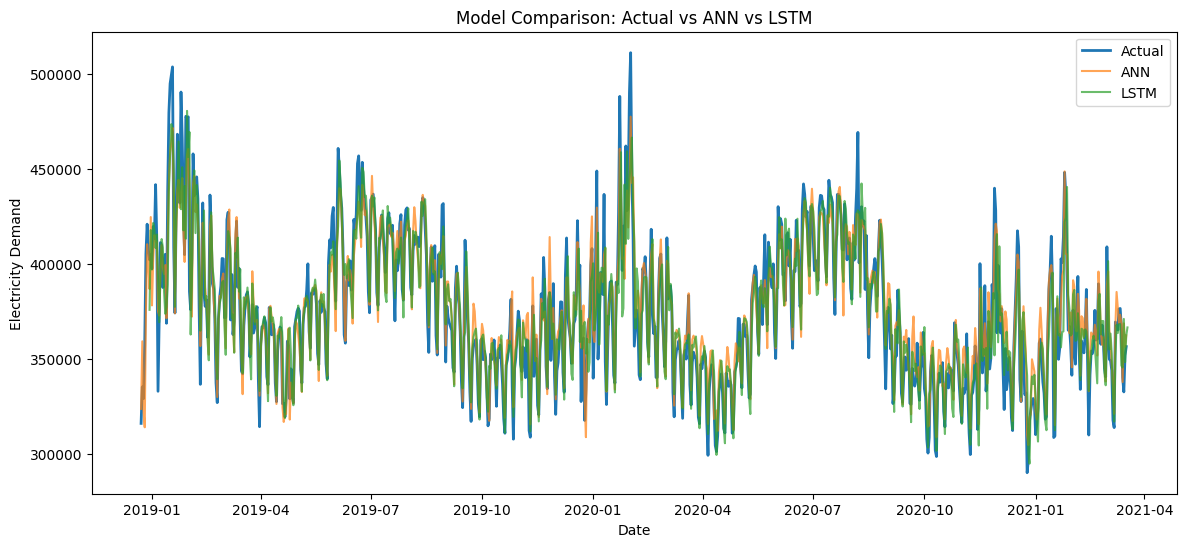

In [33]:
#initial Visualization
plt.figure(figsize=(14,6))

plt.plot(dates_ann_clean, ann_actual_clean.flatten(), label="Actual", linewidth=2)
plt.plot(dates_ann_clean, ann_pred_clean.flatten(), label="ANN", alpha=0.7)
plt.plot(dates_lstm, lstm_pred.flatten(), label="LSTM", alpha=0.7)

plt.title("Model Comparison: Actual vs ANN vs LSTM")
plt.xlabel("Date")
plt.ylabel("Electricity Demand")
plt.legend()
plt.show()

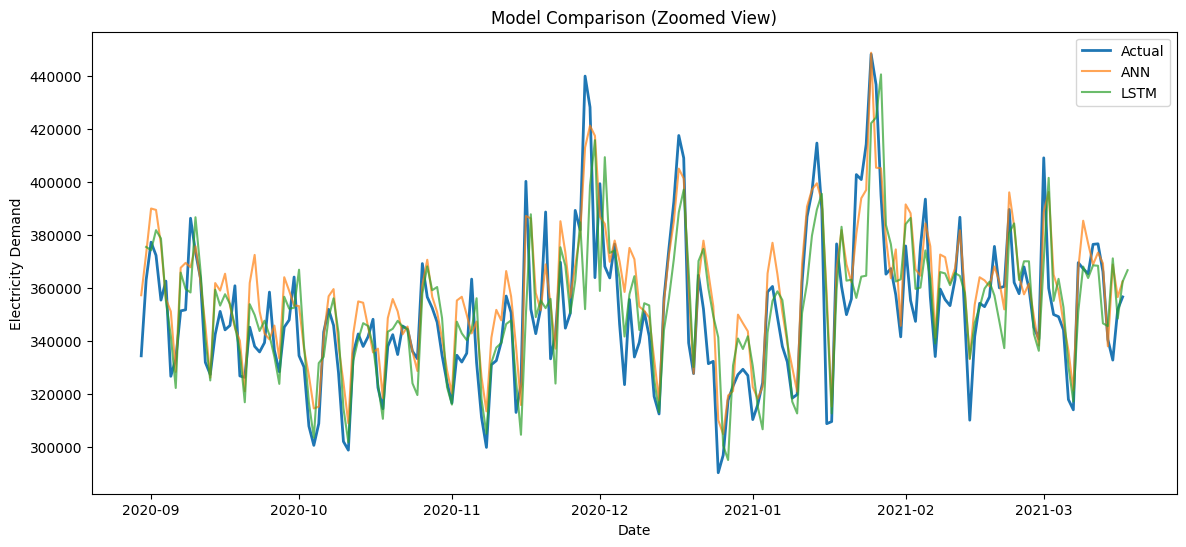

In [32]:
#Visualization
plt.figure(figsize=(14,6))

plt.plot(dates_ann_clean[-200:], ann_actual_clean.flatten()[-200:], label="Actual", linewidth=2)
plt.plot(dates_ann_clean[-200:], ann_pred_clean.flatten()[-200:], label="ANN", alpha=0.7)
plt.plot(dates_lstm[-200:], lstm_pred.flatten()[-200:], label="LSTM", alpha=0.7)

plt.title("Model Comparison (Zoomed View)")
plt.xlabel("Date")
plt.ylabel("Electricity Demand")
plt.legend()
plt.show()